# Chapter 92 — Points and Coordinate Systems

> **Prerequisites:** ch091 (Geometry in Programming)
>
> **Outcomes:** Define points formally; Understand coordinate systems as choices of reference; Convert between coordinate systems


## What Is a Point?

A **point** is a location in space — it has no size, no direction, just position.

In 2D, a point P is specified by two numbers: P = (x, y).
These are its **coordinates** relative to a chosen **coordinate system**.

A coordinate system requires:
1. An **origin** — the reference point (0, 0)
2. Two **axes** — perpendicular directions (x-axis horizontal, y-axis vertical by convention)
3. A **unit** — the scale (1 unit = 1 pixel? 1 meter? 1 parsec?)

The choice of coordinate system is arbitrary — it's a human convenience.
The geometry is real; the coordinates are labels.

**Key insight:** The distance between two points does not change when you change coordinate systems.
Only the numerical representation of their coordinates changes. This invariance is fundamental.

## Coordinate Systems in Practice

In programming, you encounter multiple coordinate systems:

| System | Origin | y-axis direction |
|--------|--------|-----------------|
| Math | bottom-left | up |
| Screen pixels | top-left | **down** |
| OpenGL | center | up |
| GPS | Earth center | complex (lat/lon/alt) |

**This matters:** if you draw math plots directly to screen coordinates, y is flipped.
`matplotlib` handles this for you. When writing graphics code from scratch, you must transform.

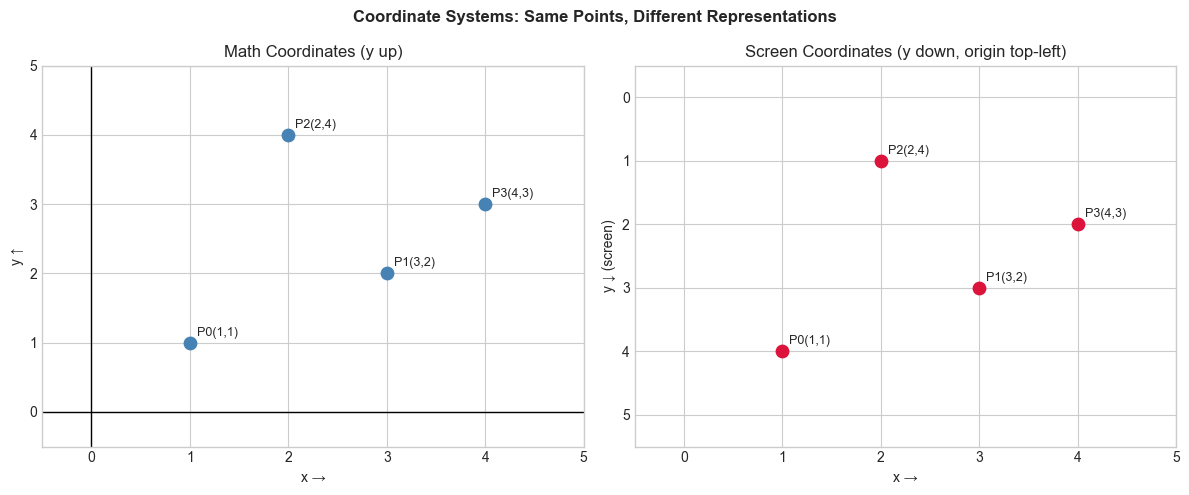

Screen (3, 1) → Math: [3 4]


In [1]:
# --- Coordinate systems demonstration ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Math coordinates (y up)
ax = axes[0]
points = np.array([[1,1],[3,2],[2,4],[4,3]])
ax.scatter(points[:,0], points[:,1], s=80, color='steelblue', zorder=5)
for i, (x,y) in enumerate(points):
    ax.annotate(f'P{i}({x},{y})', (x,y), textcoords='offset points', xytext=(5,5), fontsize=9)
ax.axhline(0, color='black', linewidth=1); ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('x →'); ax.set_ylabel('y ↑')
ax.set_title('Math Coordinates (y up)'); ax.set_xlim(-0.5, 5); ax.set_ylim(-0.5, 5)

# Screen coordinates (y down) - simulate
ax = axes[1]
H = 5  # screen height
screen_pts = points.copy(); screen_pts[:,1] = H - points[:,1]
ax.scatter(screen_pts[:,0], screen_pts[:,1], s=80, color='crimson', zorder=5)
for i, (x,y) in enumerate(screen_pts):
    ax.annotate(f'P{i}({x},{H-int(y)})', (x,y), textcoords='offset points', xytext=(5,5), fontsize=9)
ax.set_xlabel('x →'); ax.set_ylabel('y ↓ (screen)')
ax.set_title('Screen Coordinates (y down, origin top-left)')
ax.invert_yaxis()
ax.set_xlim(-0.5, 5); ax.set_ylim(5.5, -0.5)

plt.suptitle('Coordinate Systems: Same Points, Different Representations', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Transform: screen → math
def screen_to_math(p_screen, height):
    return np.array([p_screen[0], height - p_screen[1]])

print("Screen (3, 1) → Math:", screen_to_math(np.array([3, 1]), 5))

## Summary

- A point = (x, y): coordinates relative to a chosen origin and axes
- Different coordinate systems: math (y up) vs screen (y down) vs polar vs geographic
- Distance and shape are invariant; coordinates change with the system
- Always know which system you're in — coordinate bugs are subtle and common

**Forward:** ch093 deepens Cartesian coordinates; ch106 introduces polar coordinates.
**ML connection:** ch292 (Feature Engineering) uses coordinate transforms to improve model performance.